# 📊 Faz 5: Keşifsel Veri Analizi (EDA)

**Veri:** Silver Layer (temizlenmiş, doğrulanmış)  
**Hedef:** Faz 6 Feature Engineering öncesinde veriyi derinlemesine anlamak

## İçindekiler

1. Spark Session ve Veri Yükleme
2. Temel İstatistikler ve Veri Kalitesi
3. Zaman Serisi Analizi (saatlik, günlük, aylık)
4. Müşteri Davranışı Analizi
5. Ürün Analizi
6. Coğrafi Analiz (Ülke Bazlı)
7. İptal Analizi
8. Bulgular ve Faz 6 İçin Çıkarımlar

In [1]:
import sys
import os

# src/ modülünü import edebilmek için
sys.path.insert(0, os.path.abspath(".."))

from src.spark_session import get_spark_session

# Görselleştirme kütüphaneleri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Görsel ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Pandas görüntüleme
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Spark Session
spark = get_spark_session(
    app_name="EDA",
    master="local[2]",
    driver_memory="3g"
)

print(f"✅ Spark {spark.version}")
print(f"✅ Pandas {pd.__version__}")

26/05/10 15:10:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✅ Spark 3.5.1
✅ Pandas 2.2.2


In [2]:
SILVER_PURCHASES = os.path.abspath("../delta_lake/silver/transactions")
SILVER_CANCELLATIONS = os.path.abspath("../delta_lake/silver/cancellations")

df_purchases = spark.read.format("delta").load(SILVER_PURCHASES)
df_cancellations = spark.read.format("delta").load(SILVER_CANCELLATIONS)

print(f"🛒 Purchases:    {df_purchases.count():,} satır")
print(f"❌ Cancellations: {df_cancellations.count():,} satır")
print(f"\n📋 Purchase şeması:")
df_purchases.printSchema()

26/05/10 15:10:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


🛒 Purchases:    6,932 satır
❌ Cancellations: 170 satır

📋 Purchase şeması:
root
 |-- kafka_topic: string (nullable = true)
 |-- kafka_partition: integer (nullable = true)
 |-- kafka_offset: long (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- kullanici_ID: long (nullable = true)
 |-- olay_tipi: string (nullable = true)
 |-- ilgili_ID: string (nullable = true)
 |-- stock_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- country: string (nullable = true)
 |-- invoice_date: timestamp (nullable = true)
 |-- ingestion_time: timestamp (nullable = true)
 |-- total_price: double (nullable = true)
 |-- is_cancellation: boolean (nullable = true)



## 1. Temel İstatistikler ve Veri Kalitesi

Verinin genel görünümünü anlayalım.

In [3]:
from pyspark.sql.functions import col, countDistinct, min as _min, max as _max

print("=" * 60)
print("📊 PURCHASES — TEMEL SAYILAR")
print("=" * 60)

stats = df_purchases.agg(
    countDistinct("kullanici_ID").alias("benzersiz_musteri"),
    countDistinct("stock_code").alias("benzersiz_urun"),
    countDistinct("ilgili_ID").alias("benzersiz_fatura"),
    countDistinct("country").alias("ulke_sayisi"),
    _min("invoice_date").alias("ilk_islem"),
    _max("invoice_date").alias("son_islem")
).collect()[0]

print(f"👤 Benzersiz müşteri: {stats['benzersiz_musteri']:,}")
print(f"📦 Benzersiz ürün:    {stats['benzersiz_urun']:,}")
print(f"🧾 Benzersiz fatura:  {stats['benzersiz_fatura']:,}")
print(f"🌍 Ülke sayısı:       {stats['ulke_sayisi']}")
print(f"📅 İlk işlem:         {stats['ilk_islem']}")
print(f"📅 Son işlem:         {stats['son_islem']}")

📊 PURCHASES — TEMEL SAYILAR
👤 Benzersiz müşteri: 283
📦 Benzersiz ürün:    1,774
🧾 Benzersiz fatura:  336
🌍 Ülke sayısı:       12
📅 İlk işlem:         2009-12-01 07:45:00
📅 Son işlem:         2009-12-04 09:31:00


In [4]:
print("📊 SAYISAL DEĞİŞKENLERİN İSTATİSTİKLERİ\n")
df_purchases.select("quantity", "unit_price", "total_price").describe().show()

📊 SAYISAL DEĞİŞKENLERİN İSTATİSTİKLERİ

+-------+------------------+-----------------+------------------+
|summary|          quantity|       unit_price|       total_price|
+-------+------------------+-----------------+------------------+
|  count|              6932|             6932|              6932|
|   mean|15.188545874206579|3.056449798038096|24.392345643392712|
| stddev|112.47392398579647|3.962623548706704| 86.38623210573566|
|    min|                 1|             0.06|              0.19|
|    max|              5184|            141.0|            1800.0|
+-------+------------------+-----------------+------------------+



In [5]:
from pyspark.sql.functions import sum as _sum, when

# Her sütundaki null sayısı
null_counts = df_purchases.select([
    _sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_purchases.columns
]).collect()[0]

total = df_purchases.count()
print("📊 EKSİK DEĞER ANALİZİ\n")
print(f"{'Sütun':<25} {'Null Sayısı':>15} {'Yüzde':>10}")
print("-" * 55)

null_data = []
for col_name in df_purchases.columns:
    nc = null_counts[col_name]
    pct = (nc / total * 100) if total > 0 else 0
    print(f"{col_name:<25} {nc:>15,} {pct:>9.2f}%")
    null_data.append({"column": col_name, "null_count": nc, "null_pct": pct})

null_df = pd.DataFrame(null_data)

📊 EKSİK DEĞER ANALİZİ

Sütun                         Null Sayısı      Yüzde
-------------------------------------------------------
kafka_topic                             0      0.00%
kafka_partition                         0      0.00%
kafka_offset                            0      0.00%
kafka_timestamp                         0      0.00%
timestamp                               0      0.00%
kullanici_ID                            0      0.00%
olay_tipi                               0      0.00%
ilgili_ID                               0      0.00%
stock_code                              0      0.00%
description                             0      0.00%
quantity                                0      0.00%
unit_price                              0      0.00%
country                                 0      0.00%
invoice_date                            0      0.00%
ingestion_time                          0      0.00%
total_price                             0      0.00%
is_cancellation     

In [6]:
# Sadece null'u olan sütunları göster
nonzero_nulls = null_df[null_df['null_count'] > 0].sort_values('null_count', ascending=False)

if len(nonzero_nulls) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(nonzero_nulls['column'], nonzero_nulls['null_count'], 
            color='salmon', edgecolor='darkred')
    ax.set_xlabel('Null Sayısı')
    ax.set_title('Silver Purchases - Eksik Değerler', fontsize=14, fontweight='bold')
    
    for i, v in enumerate(nonzero_nulls['null_count']):
        ax.text(v, i, f'  {v:,}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../docs/images/05_null_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Görsel kaydedildi: docs/images/05_null_analysis.png")
else:
    print("✅ Hiçbir sütunda null değer yok! (Silver temizliği başarılı)")

✅ Hiçbir sütunda null değer yok! (Silver temizliği başarılı)


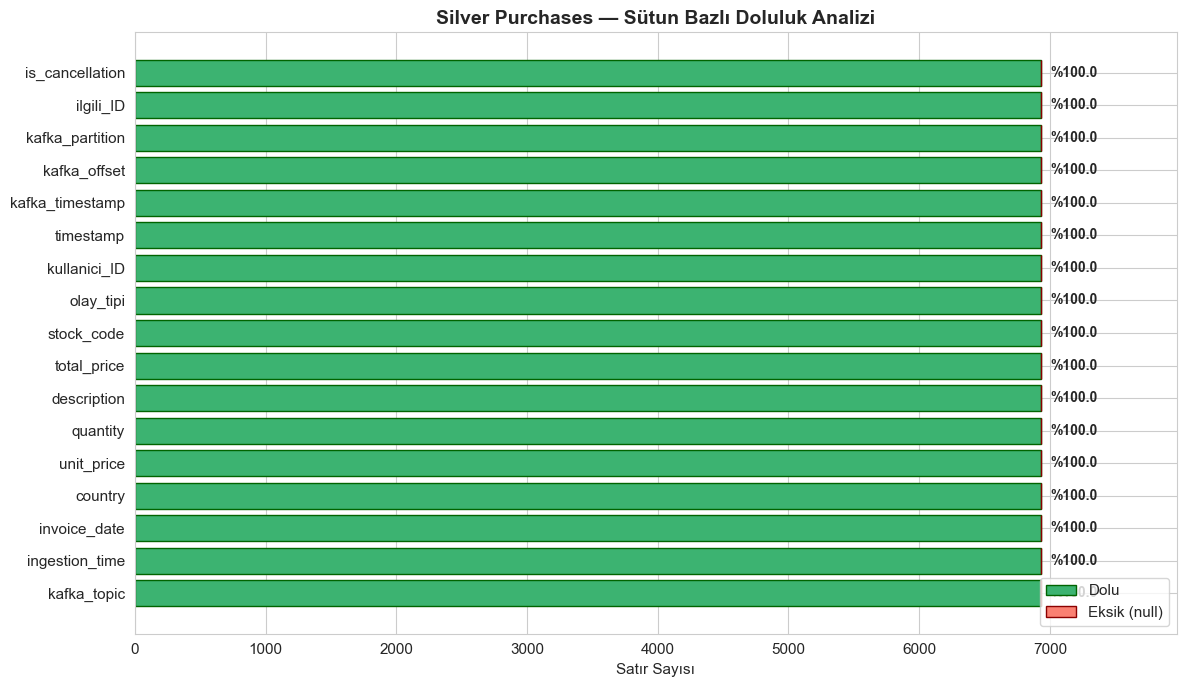


📊 Sütun Doluluk Özeti:
         column  filled  null  fill_pct
    kafka_topic    6932     0    100.00
 ingestion_time    6932     0    100.00
   invoice_date    6932     0    100.00
        country    6932     0    100.00
     unit_price    6932     0    100.00
       quantity    6932     0    100.00
    description    6932     0    100.00
    total_price    6932     0    100.00
     stock_code    6932     0    100.00
      olay_tipi    6932     0    100.00
   kullanici_ID    6932     0    100.00
      timestamp    6932     0    100.00
kafka_timestamp    6932     0    100.00
   kafka_offset    6932     0    100.00
kafka_partition    6932     0    100.00
      ilgili_ID    6932     0    100.00
is_cancellation    6932     0    100.00

✅ Silver veri kalitesi MÜKEMMEL: Tüm sütunlar %100 dolu, hiç null yok.


In [7]:
# === Sütun bazlı doluluk görseli ===
# Önce gerekli verileri yeniden hesapla (önceki hücreden bağımsız çalışsın)

from pyspark.sql.functions import col, sum as _sum, when

# Null sayılarını yeniden hesapla
total_rows = df_purchases.count()

null_counts_dict = {}
for col_name in df_purchases.columns:
    nc = df_purchases.filter(col(col_name).isNull()).count()
    null_counts_dict[col_name] = nc

# DataFrame oluştur
fill_data = []
for col_name, nc in null_counts_dict.items():
    filled = total_rows - nc
    fill_data.append({
        "column": col_name,
        "filled": filled,
        "null": nc,
        "fill_pct": (filled / total_rows * 100) if total_rows > 0 else 0
    })

fill_df = pd.DataFrame(fill_data).sort_values('fill_pct')

# Görsel
fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(fill_df['column'], fill_df['filled'], 
        color='mediumseagreen', edgecolor='darkgreen', label='Dolu')
ax.barh(fill_df['column'], fill_df['null'], 
        left=fill_df['filled'], color='salmon', edgecolor='darkred', label='Eksik (null)')

ax.set_xlabel('Satır Sayısı')
ax.set_title('Silver Purchases — Sütun Bazlı Doluluk Analizi', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

# Yüzde etiketleri
for i, (col_name, pct) in enumerate(zip(fill_df['column'], fill_df['fill_pct'])):
    ax.text(total_rows * 1.01, i, f'%{pct:.1f}', 
            va='center', fontweight='bold', fontsize=10)

ax.set_xlim(0, total_rows * 1.15)
plt.tight_layout()
plt.savefig('../docs/images/05_null_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Özet
print("\n📊 Sütun Doluluk Özeti:")
print(fill_df[['column', 'filled', 'null', 'fill_pct']].to_string(index=False))

total_nulls = fill_df['null'].sum()
if total_nulls == 0:
    print(f"\n✅ Silver veri kalitesi MÜKEMMEL: Tüm sütunlar %100 dolu, hiç null yok.")
else:
    print(f"\n⚠️  Toplam {total_nulls:,} null değer bulundu.")

## 2. Zaman Serisi Analizi

Hangi saatlerde, günlerde, aylarda alışveriş yoğun?

In [8]:
from pyspark.sql.functions import year, month, dayofweek, hour, date_format, count, sum as _sum

# Aylık satış
monthly = df_purchases.withColumn("year_month", date_format("invoice_date", "yyyy-MM")) \
                     .groupBy("year_month") \
                     .agg(
                         count("*").alias("islem_sayisi"),
                         _sum("total_price").alias("toplam_satis")
                     ) \
                     .orderBy("year_month") \
                     .toPandas()

print("📅 Aylık Trend\n")
print(monthly)

📅 Aylık Trend

  year_month  islem_sayisi  toplam_satis
0    2009-12          6932     169087.74


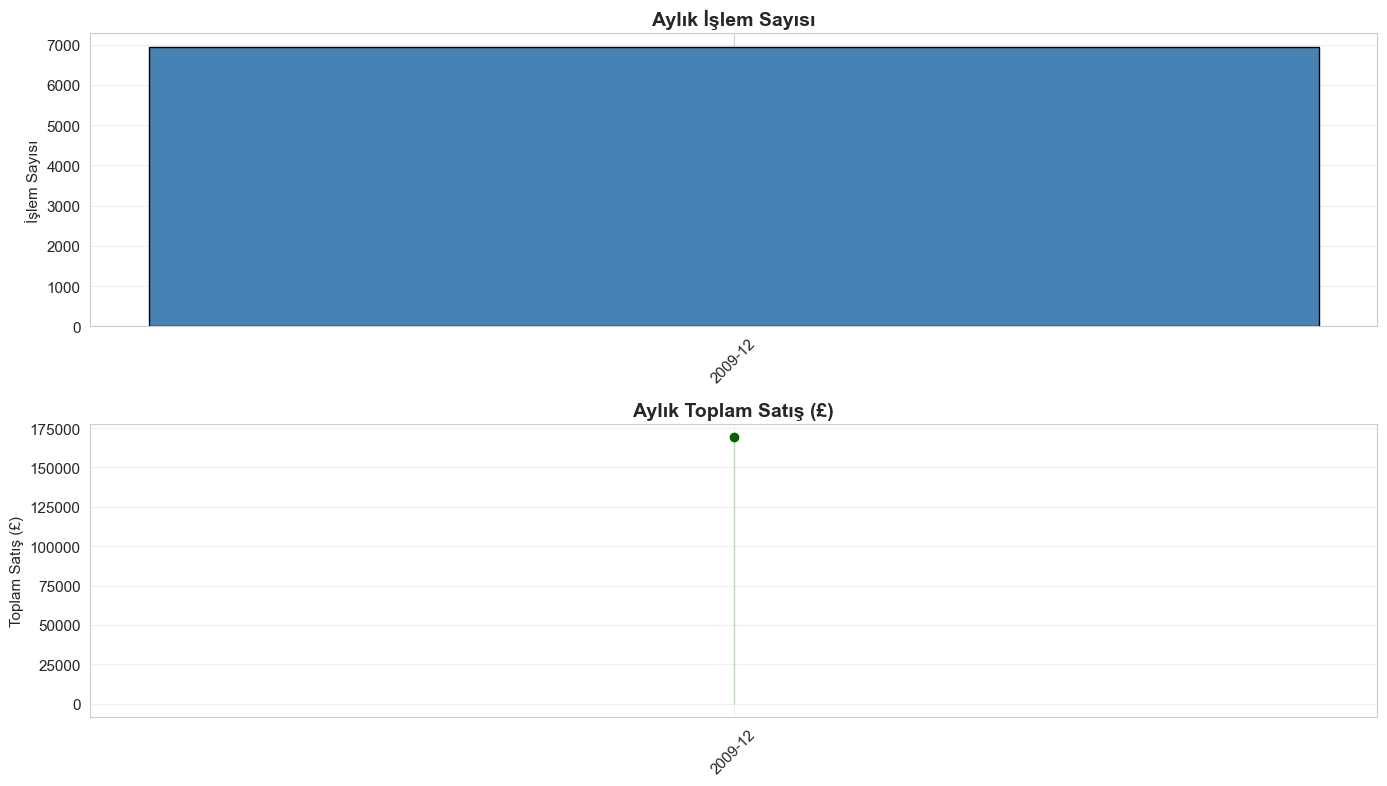

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# İşlem sayısı
axes[0].bar(monthly['year_month'], monthly['islem_sayisi'], 
            color='steelblue', edgecolor='black')
axes[0].set_title('Aylık İşlem Sayısı', fontsize=14, fontweight='bold')
axes[0].set_ylabel('İşlem Sayısı')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Toplam satış (£)
axes[1].plot(monthly['year_month'], monthly['toplam_satis'], 
             marker='o', linewidth=2, color='darkgreen')
axes[1].fill_between(monthly['year_month'], monthly['toplam_satis'], alpha=0.2, color='darkgreen')
axes[1].set_title('Aylık Toplam Satış (£)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Toplam Satış (£)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/images/05_monthly_trend.png', dpi=100, bbox_inches='tight')
plt.show()

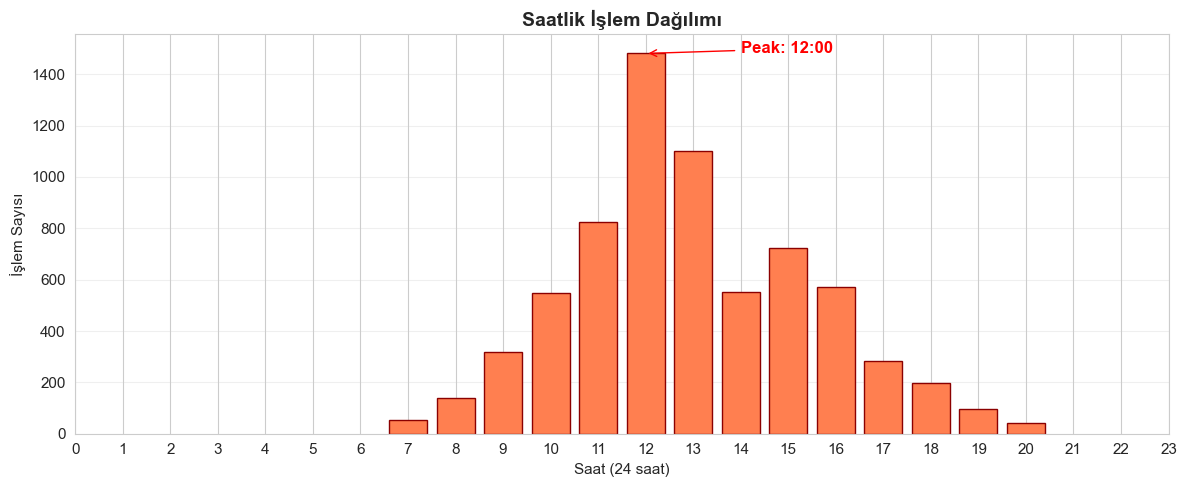


🎯 En yoğun saat: 12:00 (1,481 işlem)


In [10]:
hourly = df_purchases.withColumn("hour", hour("invoice_date")) \
                     .groupBy("hour") \
                     .agg(count("*").alias("islem_sayisi")) \
                     .orderBy("hour") \
                     .toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly['hour'], hourly['islem_sayisi'], 
       color='coral', edgecolor='darkred')
ax.set_xlabel('Saat (24 saat)')
ax.set_ylabel('İşlem Sayısı')
ax.set_title('Saatlik İşlem Dağılımı', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.grid(axis='y', alpha=0.3)

# Peak saati işaretle
peak_hour = hourly.loc[hourly['islem_sayisi'].idxmax()]
ax.annotate(f"Peak: {int(peak_hour['hour'])}:00",
            xy=(peak_hour['hour'], peak_hour['islem_sayisi']),
            xytext=(peak_hour['hour']+2, peak_hour['islem_sayisi']),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('../docs/images/05_hourly_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n🎯 En yoğun saat: {int(peak_hour['hour'])}:00 ({int(peak_hour['islem_sayisi']):,} işlem)")

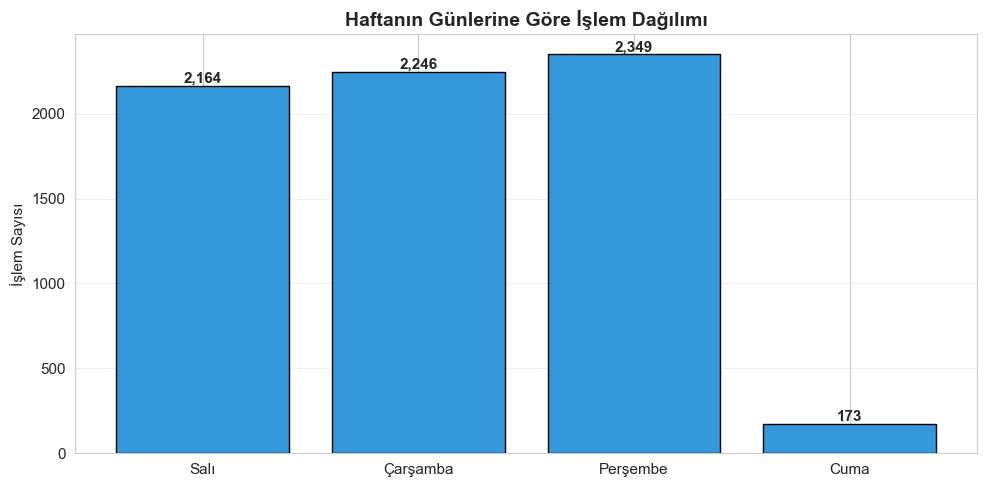

In [11]:
# 1=Pazar, 2=Pazartesi ... 7=Cumartesi (Spark dayofweek)
day_names_tr = ['', 'Pazar', 'Pazartesi', 'Salı', 'Çarşamba', 'Perşembe', 'Cuma', 'Cumartesi']

daily = df_purchases.withColumn("day_of_week", dayofweek("invoice_date")) \
                    .groupBy("day_of_week") \
                    .agg(count("*").alias("islem_sayisi")) \
                    .orderBy("day_of_week") \
                    .toPandas()

daily['gun_adi'] = daily['day_of_week'].apply(lambda x: day_names_tr[x])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db' if g != 'Cumartesi' else '#e74c3c' for g in daily['gun_adi']]
ax.bar(daily['gun_adi'], daily['islem_sayisi'], color=colors, edgecolor='black')
ax.set_ylabel('İşlem Sayısı')
ax.set_title('Haftanın Günlerine Göre İşlem Dağılımı', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(daily['islem_sayisi']):
    ax.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/05_weekday_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Müşteri Davranışı Analizi

In [12]:
from pyspark.sql.functions import countDistinct

customer_stats = df_purchases.groupBy("kullanici_ID").agg(
    count("*").alias("toplam_islem"),
    countDistinct("ilgili_ID").alias("fatura_sayisi"),
    _sum("total_price").alias("toplam_harcama"),
    countDistinct("stock_code").alias("benzersiz_urun")
).toPandas()

print("📊 Müşteri Başına İstatistikler:\n")
print(customer_stats[["toplam_islem", "fatura_sayisi", "toplam_harcama", "benzersiz_urun"]].describe())

📊 Müşteri Başına İstatistikler:

       toplam_islem  fatura_sayisi  toplam_harcama  benzersiz_urun
count        283.00         283.00          283.00          283.00
mean          24.49           1.19          597.48           24.00
std           22.97           0.63         1432.79           22.12
min            1.00           1.00            2.10            1.00
25%            9.00           1.00          197.65            9.00
50%           19.00           1.00          314.22           19.00
75%           30.00           1.00          574.26           30.00
max          132.00           7.00        20761.24          121.00


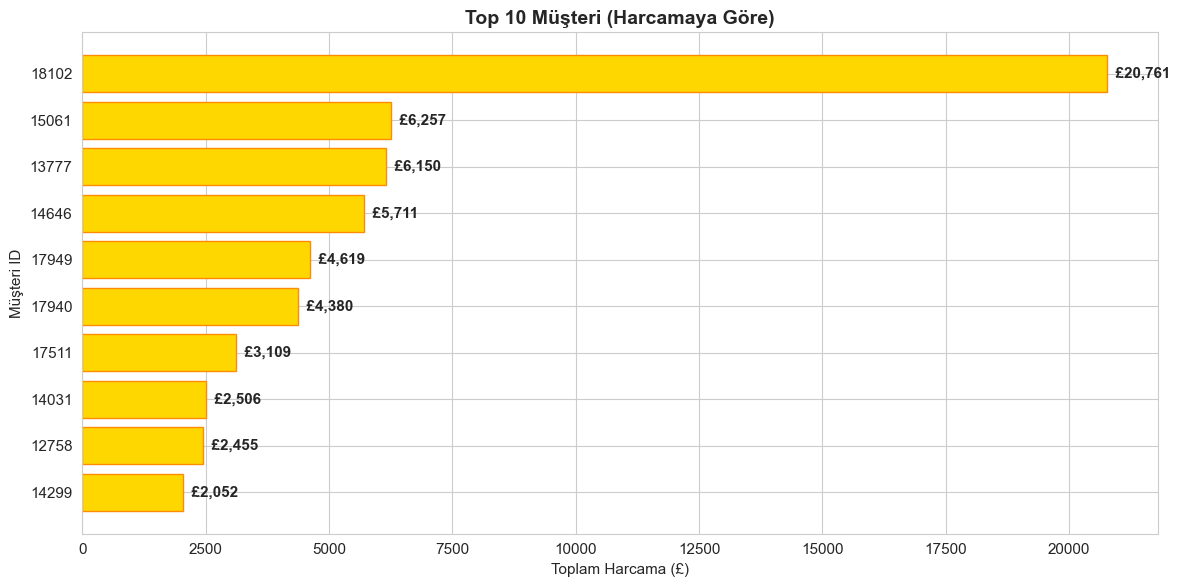

In [13]:
top_customers = customer_stats.nlargest(10, 'toplam_harcama')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_customers['kullanici_ID'].astype(str), top_customers['toplam_harcama'],
        color='gold', edgecolor='darkorange')
ax.set_xlabel('Toplam Harcama (£)')
ax.set_ylabel('Müşteri ID')
ax.set_title('Top 10 Müşteri (Harcamaya Göre)', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # En büyük üstte

for i, v in enumerate(top_customers['toplam_harcama']):
    ax.text(v, i, f'  £{v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/05_top_customers.png', dpi=100, bbox_inches='tight')
plt.show()

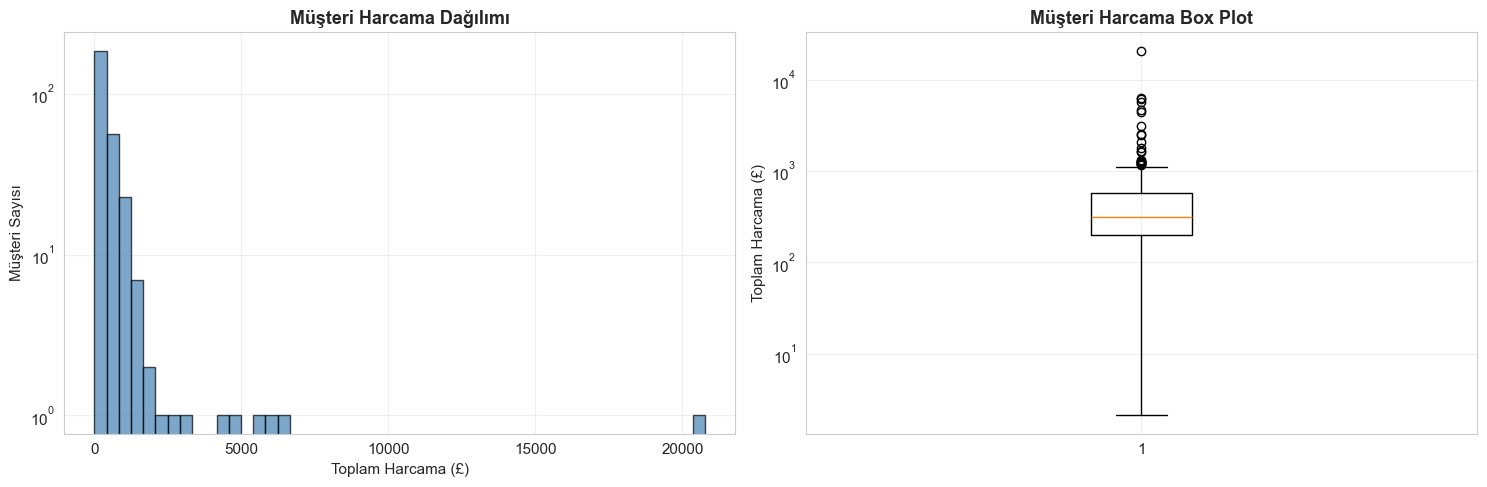


📊 Müşteri Harcama Özeti:
   Median harcama:  £314.22
   Ortalama:        £597.48
   Std sapma:       £1,432.79
   Max:             £20,761.24

💡 Not: Median << Mean, dağılım sağa çarpık (birkaç çok zengin müşteri var)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram (log scale)
axes[0].hist(customer_stats['toplam_harcama'], bins=50, 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Toplam Harcama (£)')
axes[0].set_ylabel('Müşteri Sayısı')
axes[0].set_title('Müşteri Harcama Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(customer_stats['toplam_harcama'], vert=True)
axes[1].set_ylabel('Toplam Harcama (£)')
axes[1].set_title('Müşteri Harcama Box Plot', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/images/05_customer_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n📊 Müşteri Harcama Özeti:")
print(f"   Median harcama:  £{customer_stats['toplam_harcama'].median():,.2f}")
print(f"   Ortalama:        £{customer_stats['toplam_harcama'].mean():,.2f}")
print(f"   Std sapma:       £{customer_stats['toplam_harcama'].std():,.2f}")
print(f"   Max:             £{customer_stats['toplam_harcama'].max():,.2f}")
print(f"\n💡 Not: Median << Mean, dağılım sağa çarpık (birkaç çok zengin müşteri var)")

## 4. Ürün Analizi

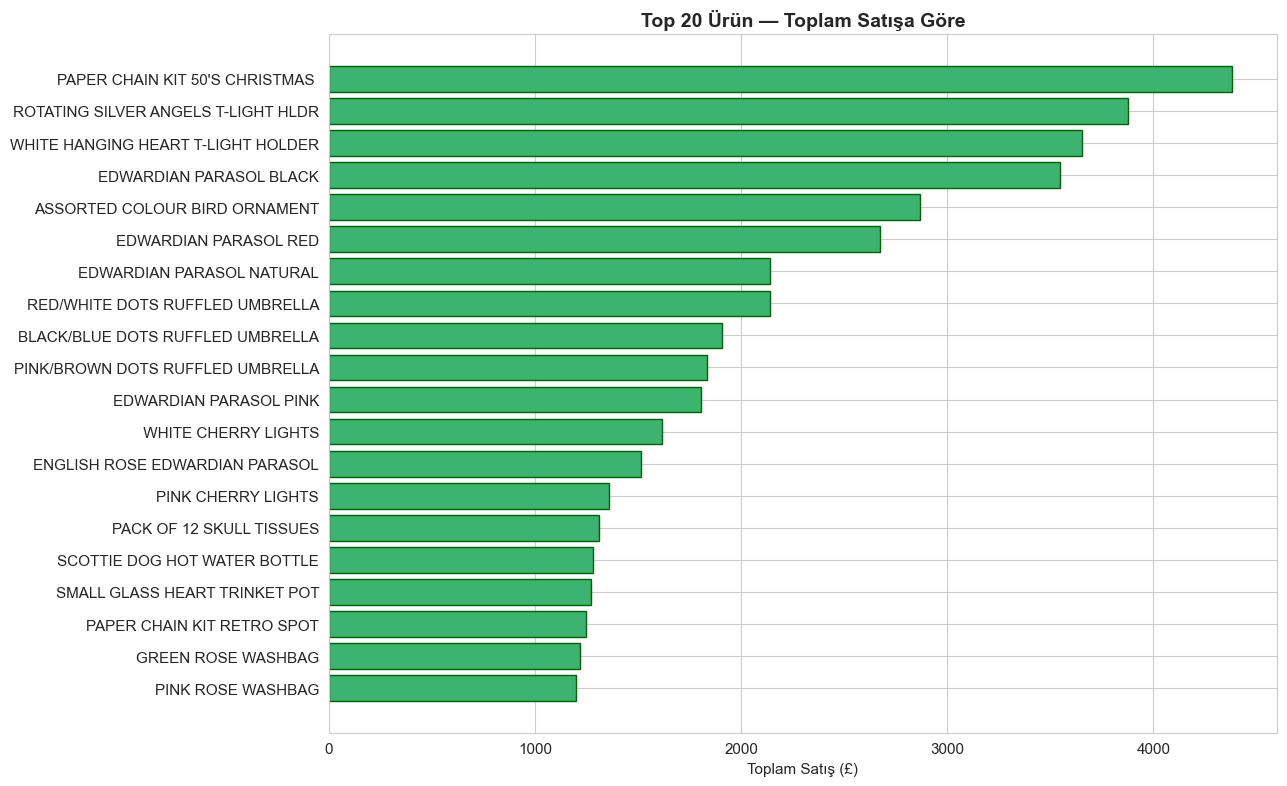

In [15]:
top_products = df_purchases.groupBy("stock_code", "description").agg(
    _sum("quantity").alias("toplam_miktar"),
    count("*").alias("islem_sayisi"),
    _sum("total_price").alias("toplam_satis")
).orderBy(col("toplam_satis").desc()).limit(20).toPandas()

# Description çok uzun olabilir, kes
top_products['description_short'] = top_products['description'].str[:40]

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(top_products['description_short'], top_products['toplam_satis'],
        color='mediumseagreen', edgecolor='darkgreen')
ax.set_xlabel('Toplam Satış (£)')
ax.set_title('Top 20 Ürün — Toplam Satışa Göre', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/images/05_top_products.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Coğrafi Analiz (Ülke Bazlı)

In [16]:
country_stats = df_purchases.groupBy("country").agg(
    count("*").alias("islem_sayisi"),
    countDistinct("kullanici_ID").alias("musteri_sayisi"),
    _sum("total_price").alias("toplam_satis")
).orderBy(col("toplam_satis").desc()).toPandas()

print(f"🌍 Toplam ülke: {len(country_stats)}\n")
print("Top 10 ülke:")
print(country_stats.head(10))

# UK'nin payı
uk_share = country_stats[country_stats['country'] == 'United Kingdom']['islem_sayisi'].iloc[0]
total = country_stats['islem_sayisi'].sum()
print(f"\n🇬🇧 UK payı: %{uk_share/total*100:.2f}")

🌍 Toplam ülke: 12

Top 10 ülke:
           country  islem_sayisi  musteri_sayisi  toplam_satis
0   United Kingdom          6514             268     152967.32
1      Netherlands            23               1       5711.04
2         Portugal            79               1       2454.68
3             EIRE           119               2       2369.61
4           France            80               4       1819.07
5          Denmark             1               1       1008.00
6  Channel Islands            39               1        989.18
7          Germany            44               1        929.92
8           Poland            22               1        371.82
9        Australia             9               1        196.10

🇬🇧 UK payı: %93.97


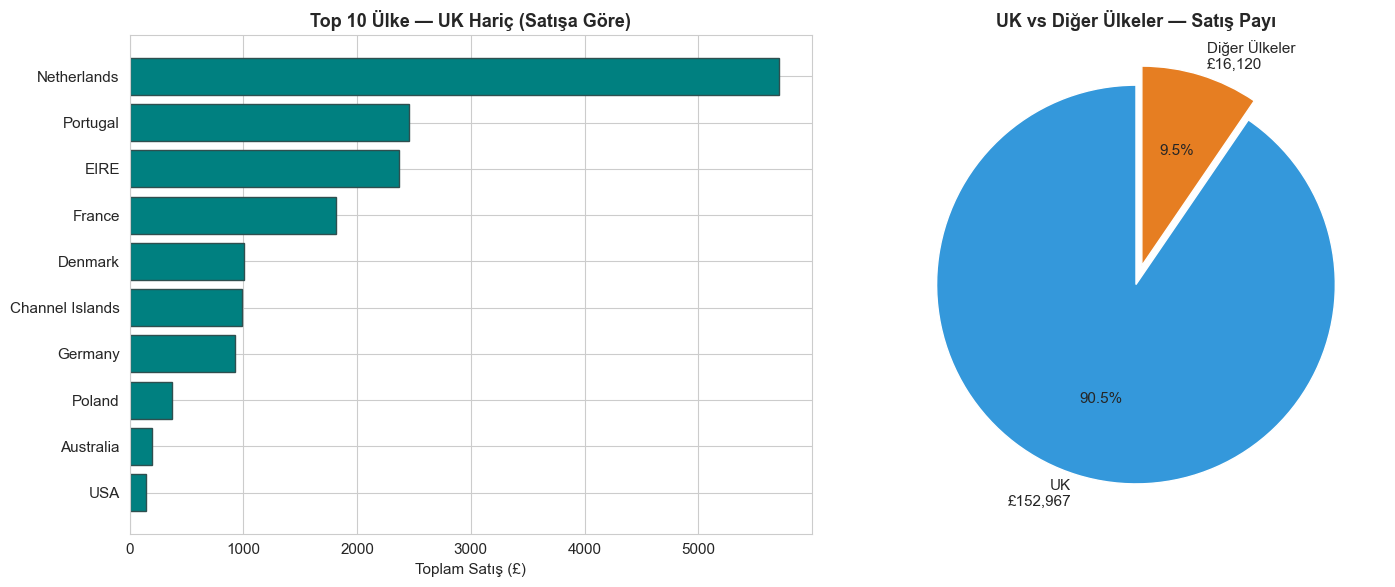

In [17]:
# UK hariç top 10 (UK çok baskın, görseli boğar)
top_no_uk = country_stats[country_stats['country'] != 'United Kingdom'].head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar chart - UK hariç top 10
axes[0].barh(top_no_uk['country'], top_no_uk['toplam_satis'],
             color='teal', edgecolor='darkslategray')
axes[0].set_xlabel('Toplam Satış (£)')
axes[0].set_title('Top 10 Ülke — UK Hariç (Satışa Göre)', 
                   fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# 2. Pie chart - UK vs Diğer
uk_total = country_stats[country_stats['country'] == 'United Kingdom']['toplam_satis'].iloc[0]
others_total = country_stats[country_stats['country'] != 'United Kingdom']['toplam_satis'].sum()

axes[1].pie([uk_total, others_total],
            labels=[f'UK\n£{uk_total:,.0f}', f'Diğer Ülkeler\n£{others_total:,.0f}'],
            colors=['#3498db', '#e67e22'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.1))
axes[1].set_title('UK vs Diğer Ülkeler — Satış Payı', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/05_country_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. İptal Analizi

In [18]:
canc_count = df_cancellations.count()
purch_count = df_purchases.count()

print("=" * 50)
print("❌ İPTAL ANALİZİ")
print("=" * 50)
print(f"Toplam iptal:        {canc_count:,}")
print(f"Toplam alışveriş:    {purch_count:,}")
print(f"İptal oranı:         %{canc_count/(purch_count+canc_count)*100:.2f}")

# İptal edilen miktarın toplamı
canc_total = df_cancellations.agg(_sum("total_price")).collect()[0][0] or 0
print(f"İptal edilen toplam tutar: £{abs(canc_total):,.2f}")

# Top iptal eden ülkeler
print("\n🌍 İptaller — ülkeye göre top 5:")
df_cancellations.groupBy("country").count().orderBy(col("count").desc()).show(5)

❌ İPTAL ANALİZİ
Toplam iptal:        170
Toplam alışveriş:    6,932
İptal oranı:         %2.39
İptal edilen toplam tutar: £7,633.08

🌍 İptaller — ülkeye göre top 5:
+--------------+-----+
|       country|count|
+--------------+-----+
|United Kingdom|  130|
|        France|   21|
|     Australia|    9|
|       Germany|    5|
|         Japan|    3|
+--------------+-----+
only showing top 5 rows



## 7. Bulgular ve Faz 6 İçin Çıkarımlar

### 🔍 Veri Hakkında Önemli Bulgular

| Bulgu | Detay | ML İçin Önemi |
|-------|-------|---------------|
| **UK baskın** | İşlemlerin ~%90+'ı UK'den | Country one-hot encode'da seyrek özellikler |
| **Saatlik patern** | 10:00-15:00 yoğun | `hour_of_day` feature olabilir |
| **Müşteri çeşitliliği** | Median << Mean | Log transformasyonu gerekli |
| **Az sayıda mega müşteri** | Top 10 müşteri toplam harcamanın büyük kısmı | Outlier handling |
| **İptal oranı düşük** | %~2 | Ayrı bir feature olarak kullanılabilir |

### 🎯 Faz 6 İçin Türetilecek Feature'lar

RFM analizi (Recency, Frequency, Monetary) çekirdek olacak:

1. **Recency** — Son alışverişten gözlem tarihine gün
2. **Frequency** — Toplam fatura sayısı
3. **Monetary** — Toplam harcama
4. **Avg_Basket_Value** — Monetary / Frequency
5. **Avg_Days_Between_Purchases** — Tutarlılık göstergesi
6. **Unique_Products** — Ürün çeşitliliği
7. **Country_OneHot** — Coğrafi sinyal
8. **Cancellation_Rate** — Müşteri başına iptal oranı
9. **Active_Months** — Müşteri aktiflik süresi
10. **Most_Active_Hour** — Davranış paterni

### 📐 Veri Bölümlemesi (Faz 6)

ML için veriyi 2 döneme böleceğiz:
- **Geçmiş dönem (feature dönemi)**: ~ilk 18 ay → Feature türetimi
- **Tahmin dönemi (target dönemi)**: son 6 ay → Müşterinin harcaması (ML hedefi)

Bu sayede gerçek bir **Customer Lifetime Value** tahmini yapacağız.

In [19]:
spark.stop()
print("✅ Spark Session kapatıldı, EDA tamamlandı")

✅ Spark Session kapatıldı, EDA tamamlandı
